# Решение ДЗ Ultra Pro: предсказание цен на машины (Юла)

**Задание.** На базе машин с Юлы обучить модель для предсказания цен.

1. Создать **обучающую, тестовую и проверочную** выборки.
2. Оценить качество работы созданной сети — определить **средний процент ошибки на проверочной выборке** (для этого предсказанные значения нужно привести к первоначальному диапазону цен).
3. Подсчитать ошибку на каждом примере **тестовой** выборки и суммарный процент ошибки.

**Рекомендации из задания:**
- Loss — `mse`.
- Метрику можно не использовать.
- Последний слой — 1 нейрон (регрессия).
- Суммарный процент ошибки = средний модуль ошибки (MAE) / средняя цена машины. Если средняя цена 560 000 ₽, а средняя ошибка 56 000 ₽ — процент ошибки 10%.

**Стратегия решения:**
1. Загрузить и осмотреть датасет (`df.head()`, `df.dtypes`, пропуски).
2. Автоматически разделить признаки на числовые и категориальные.
3. Категориальные — `one-hot`, числовые — `StandardScaler`. Цену тоже нормируем (для стабильности обучения), после предсказания — обратно денормируем.
4. Разбить на **3 выборки**: train (70%) / val (15%) / test (15%).
5. Обучить нейронную сеть с loss=mse, без метрики, последний слой `Dense(1, linear)`.
6. Привести предсказания к исходному диапазону цен и посчитать процент ошибки на проверочной (`val`) и тестовой (`test`) выборках.


## 1. Импорты

In [1]:
# Работа с массивами и таблицами
import numpy as np
import pandas as pd

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Прочее
from sklearn.preprocessing import StandardScaler
import gdown
import matplotlib.pyplot as plt

%matplotlib inline

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 2. Загрузка и осмотр данных
Скачиваем CSV, смотрим первые строки и типы столбцов — это нужно, чтобы корректно отделить числовые признаки от категориальных.

In [2]:
# Загрузка
gdown.download(
    'https://storage.yandexcloud.net/aiueducation/Content/base/l10/cars_new.csv',
    None, quiet=True
)

# Чтение — пробуем utf-8, при ошибке переключаемся на cp1251
try:
    df = pd.read_csv('cars_new.csv')
except UnicodeDecodeError:
    df = pd.read_csv('cars_new.csv', encoding='cp1251')

print('Размер:', df.shape)
df.head()


Размер: (70119, 10)


,mark,model,price,year,mileage,body,kpp,fuel,volume,power
0,kia,cerato,996000,2018,28000,седан,автомат,бензин,2.0,150.0
1,daewoo,nexia 1 поколение [2-й рестайлинг],140200,2012,60500,седан,механика,бензин,1.5,80.0
2,suzuki,jimny 3 поколение [рестайлинг],750000,2011,29000,внедорожник,автомат,бензин,1.3,85.0
3,bmw,x1 18 e84 [рестайлинг],970000,2014,49500,кроссовер,автомат,бензин,2.0,150.0
4,chevrolet,lacetti 1 поколение,205000,2007,151445,седан,механика,бензин,1.4,95.0


In [3]:
# Типы столбцов и пропуски
print('--- dtypes ---')
print(df.dtypes)
print()
print('--- Пропуски по столбцам ---')
print(df.isna().sum())


--- dtypes ---
mark        object
model       object
price        int64
year         int64
mileage      int64
body        object
kpp         object
fuel        object
volume     float64
power      float64
dtype: object

--- Пропуски по столбцам ---
mark       0
model      0
price      0
year       0
mileage    0
body       3
kpp        4
fuel       0
volume     0
power      0
dtype: int64


In [4]:
# Базовая статистика
df.describe(include='all').T.head(20)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
mark,70119,21,toyota,4043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,70119,3156,matiz m150 [рестайлинг],1062,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,70119.0,NaN,NaN,NaN,527726.101428,623684.164082,16000.0,205000.0,380000.0,640000.0,24500000.0
year,70119.0,NaN,NaN,NaN,2007.228668,7.086385,1949.0,2004.0,2008.0,2012.0,2019.0
mileage,70119.0,NaN,NaN,NaN,162237.510988,95872.148255,1.0,96980.0,147000.0,210000.0,999999.0
body,70116,16,седан,29455,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kpp,70115,4,механика,31053,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel,70119,5,бензин,63719,NaN,NaN,NaN,NaN,NaN,NaN,NaN
volume,70119.0,NaN,NaN,NaN,1.917526,0.671154,0.3,1.6,1.8,2.0,10.0
power,70119.0,NaN,NaN,NaN,136.473381,59.05425,11.0,102.0,123.0,152.0,1400.0


## 3. Подготовка данных

**Что делаем:**
1. Целевой столбец — `price` (цена машины). Если в датасете он называется иначе, скрипт ниже сам подберёт подходящее имя.
2. Удаляем пропуски (или заполняем их — для простоты `dropna()`).
3. Числовые признаки оставляем как есть, потом нормируем.
4. Категориальные — one-hot через `pd.get_dummies`.
5. Таргет (`price`) нормируем `StandardScaler`-ом — обучение регрессии так идёт быстрее и стабильнее.

In [5]:
# Подбираем имя целевого столбца
target_col = None
for cand in ['price', 'Price', 'цена', 'Цена', 'cost', 'value']:
    if cand in df.columns:
        target_col = cand
        break

if target_col is None:
    # Берём столбец, который похож на цену по смыслу
    # (числовой, с большим средним и большим std)
    numeric = df.select_dtypes(include=[np.number])
    target_col = numeric.mean().idxmax()

print(f'Целевой столбец: {target_col!r}')
print(f'Средняя цена: {df[target_col].mean():,.0f}')
print(f'Мин/Макс:     {df[target_col].min():,.0f} / {df[target_col].max():,.0f}')


Целевой столбец: 'price'
Средняя цена: 527,726
Мин/Макс:     16,000 / 24,500,000


In [6]:
# Удаляем пропуски и явные выбросы
data = df.dropna().copy()

# Иногда в таких датасетах цена бывает 0 или мусорной — отфильтруем
data = data[data[target_col] > 0]

# (Опционально) убираем 0.5% самых дорогих машин — обычно это «суперкары»,
# которые сбивают регрессию
hi = data[target_col].quantile(0.995)
data = data[data[target_col] <= hi]

print('После очистки:', data.shape)
print(f'Средняя цена после очистки: {data[target_col].mean():,.0f}')


После очистки: (69761, 10)
Средняя цена после очистки: 502,007


In [7]:
# Разделяем на признаки и target
y_full = data[target_col].values.astype(np.float32)
X_full = data.drop(columns=[target_col])

# Числовые и категориальные столбцы
num_cols = X_full.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_full.select_dtypes(exclude=[np.number]).columns.tolist()

print('Числовых признаков:    ', len(num_cols), '->', num_cols)
print('Категориальных признаков:', len(cat_cols), '->', cat_cols)


Числовых признаков:     4 -> ['year', 'mileage', 'volume', 'power']
Категориальных признаков: 5 -> ['mark', 'model', 'body', 'kpp', 'fuel']


In [8]:
# One-hot кодирование категориальных
X_encoded = pd.get_dummies(X_full, columns=cat_cols, drop_first=False)

# Приводим всё к float32 (after dummies некоторые столбцы могут быть bool/uint8)
X_encoded = X_encoded.astype(np.float32)

print('После one-hot:', X_encoded.shape)


После one-hot: (69761, 3161)


## 4. Разбиение на 3 выборки: train / val / test

По заданию нужны **обучающая, тестовая и проверочная** выборки. Делим: 70% train, 15% val, 15% test. Делается одной маской на основе случайных индексов с фиксированным `seed` — чтобы результаты воспроизводились.

In [9]:
# Перемешиваем индексы
rng = np.random.default_rng(SEED)
n   = len(X_encoded)
idx = rng.permutation(n)

n_tr  = int(n * 0.70)
n_val = int(n * 0.15)

idx_tr   = idx[:n_tr]
idx_val  = idx[n_tr:n_tr + n_val]
idx_test = idx[n_tr + n_val:]

X_tr,  y_tr   = X_encoded.values[idx_tr],   y_full[idx_tr]
X_val, y_val  = X_encoded.values[idx_val],  y_full[idx_val]
X_test, y_test = X_encoded.values[idx_test], y_full[idx_test]

print('Train:', X_tr.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)


Train: (48832, 3161) Val: (10464, 3161) Test: (10465, 3161)


In [10]:
# Нормируем X (по train) — fit ТОЛЬКО на train, иначе утечка
x_scaler = StandardScaler()
X_tr_sc   = x_scaler.fit_transform(X_tr).astype(np.float32)
X_val_sc  = x_scaler.transform(X_val).astype(np.float32)
X_test_sc = x_scaler.transform(X_test).astype(np.float32)

# Нормируем y (по train)
y_scaler = StandardScaler()
y_tr_sc   = y_scaler.fit_transform(y_tr.reshape(-1, 1)).astype(np.float32)
y_val_sc  = y_scaler.transform(y_val.reshape(-1, 1)).astype(np.float32)
y_test_sc = y_scaler.transform(y_test.reshape(-1, 1)).astype(np.float32)

INPUT_DIM = X_tr_sc.shape[1]
print('INPUT_DIM =', INPUT_DIM)


INPUT_DIM = 3161


## 5. Модель

Согласно рекомендациям задания:
- Loss — `mse`.
- Метрику не задаём (как в задании).
- Последний слой — `Dense(1, activation='linear')`.

Архитектура: глубокая полносвязная сеть с `BatchNormalization` на входе и `Dropout` для регуляризации — для разнородных табличных данных это хорошо работает.

In [11]:
model = Sequential([
    BatchNormalization(input_dim=INPUT_DIM),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64,  activation='relu'),
    Dense(1,   activation='linear'),
])

model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 3161)           │        12,644 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       809,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 863,333 (3.29 MB)

 Trainable params: 857,011 (3.27 MB)

 Non-trainable params: 6,322 (24.70 KB)

## 6. Обучение модели
- `ModelCheckpoint` сохраняет веса лучшей эпохи по `val_loss`.
- `EarlyStopping` останавливает обучение, если `val_loss` не улучшается 15 эпох подряд.

In [12]:
checkpoint = ModelCheckpoint(
    'best_cars.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=0,
)
early_stop = EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=False, verbose=1
)

history = model.fit(
    X_tr_sc, y_tr_sc,
    validation_data=(X_val_sc, y_val_sc),
    epochs=150,
    batch_size=256,
    verbose=0,
    callbacks=[checkpoint, early_stop],
)

model.load_weights('best_cars.weights.h5')
print(f'\nЛучший val_loss (нормированный): {min(history.history["val_loss"]):.4f}')


Epoch 17: early stopping

Лучший val_loss (нормированный): 1.0216


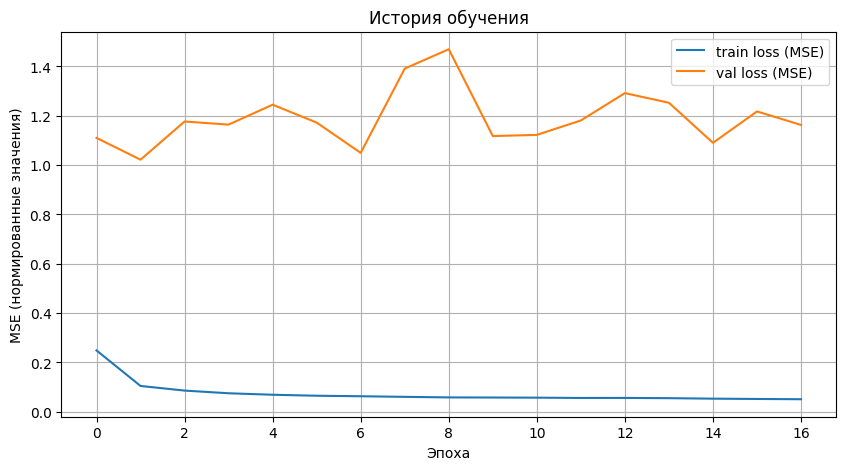

In [13]:
# График обучения
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'],     label='train loss (MSE)')
plt.plot(history.history['val_loss'], label='val loss (MSE)')
plt.xlabel('Эпоха')
plt.ylabel('MSE (нормированные значения)')
plt.title('История обучения')
plt.legend(); plt.grid(); plt.show()


## 7. Оценка на проверочной выборке (пункт 2 задания)

> Определите средний процент ошибки на проверочной выборке. Для этого приводим предсказания к первоначальному диапазону цен.

Формула: **процент ошибки = MAE / средняя цена × 100%**.

In [14]:
# Предсказания на val + обратная нормировка
pred_val_sc  = model.predict(X_val_sc, verbose=0)
pred_val     = y_scaler.inverse_transform(pred_val_sc).ravel()

# Средний модуль ошибки и процент ошибки
mae_val      = float(np.mean(np.abs(pred_val - y_val)))
mean_price   = float(y_val.mean())
err_pct_val  = mae_val / mean_price * 100

print(f'MAE val            : {mae_val:,.0f} руб.')
print(f'Средняя цена val   : {mean_price:,.0f} руб.')
print(f'Средний % ошибки   : {err_pct_val:.2f}%')


MAE val            : 188,334 руб.
Средняя цена val   : 505,963 руб.
Средний % ошибки   : 37.22%


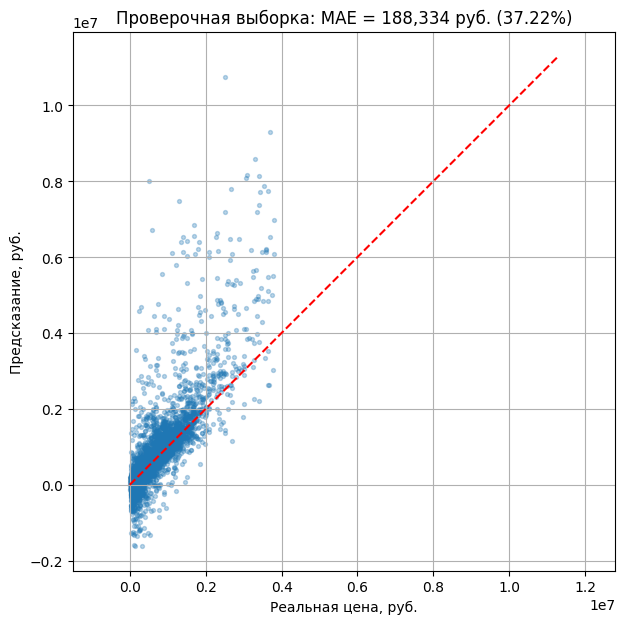

In [15]:
# Скаттер «истинная цена vs предсказание» на val
plt.figure(figsize=(7, 7))
plt.scatter(y_val, pred_val, alpha=0.3, s=8)
lim = (0, max(y_val.max(), pred_val.max()) * 1.05)
plt.plot(lim, lim, 'r--')
plt.xlim(lim); plt.ylim(lim)
plt.xlabel('Реальная цена, руб.')
plt.ylabel('Предсказание, руб.')
plt.title(f'Проверочная выборка: MAE = {mae_val:,.0f} руб. ({err_pct_val:.2f}%)')
plt.grid(); plt.axis('equal'); plt.show()


## 8. Оценка на тестовой выборке (пункт 3 задания)

> Подсчитайте ошибку на **каждом примере** тестовой выборки и **суммарный процент ошибки**.

In [16]:
# Предсказания на test + обратная нормировка
pred_test_sc = model.predict(X_test_sc, verbose=0)
pred_test    = y_scaler.inverse_transform(pred_test_sc).ravel()

# Ошибка на каждом примере
errors_abs   = np.abs(pred_test - y_test)        # модуль ошибки в рублях
errors_pct   = errors_abs / y_test * 100         # процент ошибки на каждой машине

# Сводные метрики
mae_test     = float(errors_abs.mean())
mean_price_t = float(y_test.mean())
err_pct_test = mae_test / mean_price_t * 100     # суммарный % ошибки (по заданию)
mean_pct_per = float(errors_pct.mean())          # средний % ошибки по объектам

print(f'Размер test                  : {len(y_test)}')
print(f'MAE test                     : {mae_test:,.0f} руб.')
print(f'Средняя цена test            : {mean_price_t:,.0f} руб.')
print(f'Суммарный процент ошибки     : {err_pct_test:.2f}%   (MAE / средняя цена)')
print(f'Средний % ошибки по примерам : {mean_pct_per:.2f}%   (среднее |Δ| / цена)')


Размер test                  : 10465
MAE test                     : 179,216 руб.
Средняя цена test            : 502,144 руб.
Суммарный процент ошибки     : 35.69%   (MAE / средняя цена)
Средний % ошибки по примерам : 62.98%   (среднее |Δ| / цена)


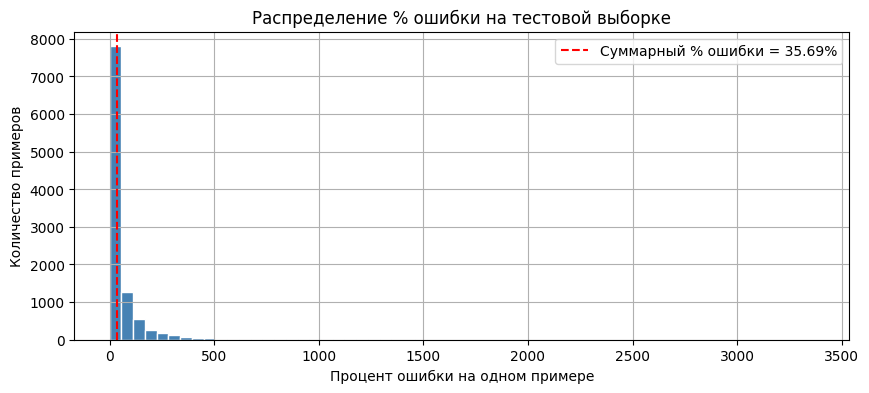

In [17]:
# Распределение ошибки в процентах по тестовым примерам
plt.figure(figsize=(10, 4))
plt.hist(errors_pct, bins=60, color='steelblue', edgecolor='white')
plt.axvline(err_pct_test, color='red', linestyle='--',
            label=f'Суммарный % ошибки = {err_pct_test:.2f}%')
plt.xlabel('Процент ошибки на одном примере')
plt.ylabel('Количество примеров')
plt.title('Распределение % ошибки на тестовой выборке')
plt.legend(); plt.grid(); plt.show()


In [18]:
# Таблица ошибок по каждому тестовому примеру (первые 15)
errors_df = pd.DataFrame({
    'Реальная цена': y_test,
    'Предсказание':  pred_test.round(0),
    '|Ошибка|':      errors_abs.round(0),
    '% ошибки':      errors_pct.round(2),
}).sort_values('|Ошибка|', ascending=False).reset_index(drop=True)

print('Топ-15 худших по абсолютной ошибке:')
errors_df.head(15)


Топ-15 худших по абсолютной ошибке:


,Реальная цена,Предсказание,|Ошибка|,% ошибки
0,1780000.0,9009945.0,7229945.0,406.179993
1,2399999.0,8468828.0,6068829.0,252.869995
2,2000000.0,7973653.0,5973653.0,298.679993
3,3399000.0,9172041.0,5773041.0,169.850006
4,680000.0,6231616.0,5551616.0,816.409973
5,1999000.0,7527563.0,5528563.0,276.570007
6,3749000.0,9275781.0,5526781.0,147.419998
7,2475000.0,7927084.0,5452084.0,220.289993
8,3199000.0,8627285.0,5428285.0,169.690002
9,830000.0,6184650.0,5354650.0,645.140015


In [19]:
print('Топ-15 лучших (минимальная ошибка):')
errors_df.tail(15).sort_values('|Ошибка|').reset_index(drop=True)


Топ-15 лучших (минимальная ошибка):


,Реальная цена,Предсказание,|Ошибка|,% ошибки
0,405000.0,404989.0,11.0,0.00
1,470000.0,469987.0,13.0,0.00
2,450000.0,449974.0,26.0,0.01
3,520000.0,519970.0,30.0,0.01
4,210000.0,209936.0,64.0,0.03
5,480000.0,480076.0,76.0,0.02
6,400000.0,399916.0,84.0,0.02
7,775000.0,775090.0,90.0,0.01
8,585000.0,585140.0,140.0,0.02
9,280000.0,280144.0,144.0,0.05
